# Lecture 6 — Hydrogen Lines: Stark Broadening

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Say why **hydrogen lines are routed to a dedicated profile engine** in this pipeline, separate from the Voigt kernel that treats the metal and helium lines in this window — the degeneracy of hydrogen's levels makes it sensitive to the **linear Stark effect**, which produces wings far broader than a Doppler-plus-Lorentz Voigt profile.
- Write down the **Holtsmark electric microfield**: the normal field strength $F_0 = 1.25\times10^{-9}\,n_e^{2/3}$ and the dimensionless detuning $\beta = \Delta\nu/F_0\cdot \mathrm{d}\beta$ that the whole profile is a function of.
- Assemble the **HPROF4 profile** as a sum of three pieces — a Doppler **core** over the fine-structure components, a **Lorentzian** (resonance + radiative + van der Waals), and the **linear-Stark wing** (a quasi-static Holtsmark term plus an electron-impact term) — selected by which half-width dominates.
- Walk the profile **outward from line centre** with the same continuum-cutoff and continuum-merge taper the production code uses, forming $\kappa_0 = \mathrm{cgf}\cdot n/\rho/v_D \cdot e^{-\chi/kT}$ at each depth.
- Explain why the **H$\beta$ Stark wing** (centred at 486 nm) deposits a smooth opacity floor across 500–510 nm — the piece the metal/He line list does not contain — and reproduce the hydrogen-line opacity to **machine precision**.

## Introduction

The line-list lecture treated every line the same way: a **Voigt profile**, the convolution of a Gaussian Doppler core with a Lorentzian wing. The Gaussian comes from thermal and turbulent motion; the Lorentzian represents the finite coherence lifetime of the transition — radiative decay of its upper and lower levels, plus collisional broadening and dephasing (the quadratic-Stark and van der Waals terms). That recipe reproduces the metal lines and the helium lines in this window to the bit. Physically, those non-hydrogenic atoms lack hydrogen's exact $n,\ell$ degeneracy, so their levels respond to an electric field only at **second order**: the perturbation goes as the *square* of a passing charge's field and falls off as $1/r^4$. Because that interaction is so short-ranged, collisions are brief and isolated — the **impact approximation** holds, and it yields a Lorentzian wing. The line stays narrow and the Voigt picture works.

Hydrogen is the exception, and it is the exception that matters most. Its energy levels are **degenerate**: states of the same principal quantum number $n$ but different angular momentum $\ell$ have (almost) the same energy. A degenerate level responds to an electric field at **first order** — the **linear Stark effect** — so the level splits *linearly* with the field rather than quadratically. The interaction is now long-ranged ($1/r^2$): the atom feels the slowly-varying combined field of *many* surrounding ions at once, the **quasi-static** limit, rather than a sequence of isolated impacts. The splitting is therefore far larger, and the line wings extend enormously. The broad wings of a hydrogen Balmer line in a stellar photosphere are dominated not by a single lifetime damping width but by the **electric microfield** of the surrounding plasma. (The hydrogenic He II ion shares the same degeneracy and the same linear-Stark sensitivity; it simply does not contribute in this window.)

That changes both the physics and the bookkeeping. The microfield is not a single number — it is a *distribution* of field strengths. The slow, quasi-static part is associated mainly with the **ionic microfield**, approximately Holtsmark distributed, and the line profile is the average of the linearly-split line over that distribution; the fast electrons enter separately, through an impact-broadening term added below. The production code handles all of this with a dedicated engine, `HPROF4` (the HLINOP family of routines), separate from the Voigt kernel that does everything else. This lecture rebuilds it.

The concrete payoff for our 500–510 nm window: the H$\beta$ line sits at 486 nm, outside the window — but its **linear-Stark wing is so broad that it reaches across 500–510 nm**, depositing a smooth opacity floor that climbs to $\sim 5.7\times10^4$ in the deepest, hottest layers. The metal-and-helium line list contains nothing there. Without the hydrogen engine, the deep-layer line opacity in this window would be missing its largest contributor.

## The bridge from the line list: why a Voigt profile is not enough

Recall the Voigt damping parameter from the line-list lecture (Lecture 5), $a = \gamma_{\rm tot}/(4\pi\,\Delta\nu_D)$, where $\gamma_{\rm tot} = \gamma_{\rm rad} + \gamma_{\rm Stark}\,n_e + \gamma_{\rm vdW}\,n_{\rm pert}$ is the sum of the radiative, (quadratic) Stark, and van der Waals damping rates, and $\Delta\nu_D$ is the Doppler width (built in Lectures 4–5 from the thermal-plus-turbulent velocity; we reuse it here unchanged). For a metal line $a$ is a small number ($\sim 10^{-2}$): the wing is a faint Lorentzian skirt on a Gaussian core, and the line is a few Doppler widths wide.

For hydrogen the **linear** Stark effect makes the wing decay as a *power law* in detuning, not the Lorentzian $1/\Delta\nu^2$. In the quasi-static limit the wing of a hydrogen line falls off as

$$
\phi(\Delta\nu) \;\propto\; \Delta\nu^{-5/2},
$$

the Holtsmark asymptotic form, set by the *field distribution* rather than a single damping rate. The far-tail exponent $-5/2$ is in fact *steeper* than the Lorentzian's $-2$; the reason a hydrogen wing is so much larger than a metal-line wing is not the exponent but the *scale*. The linear-Stark splitting is enormous compared with a lifetime width, so over the tens of nanometres of detuning that matter for a stellar spectrum the Balmer wing sits vastly higher than any Voigt profile built from metal-line damping parameters, and it carries that strength through the transition region where the simple power law has not yet set in. A Voigt profile cannot represent this — its functional form is wrong. So hydrogen gets its own profile function, built around the microfield rather than around a damping parameter.

Everything else about how a line enters the opacity is unchanged: a line centre, a line-strength prefactor $\kappa_0$, a profile $\phi$ in the code's normalisation convention (combined with $\kappa_0$ so that $\kappa_0\,\phi$ carries the desired opacity units), and a walk outward from the centre accumulating $\kappa_0\,\phi$ until it drops below a fraction of the continuum. Only the profile $\phi$ is replaced. We start from the data, then build the profile, then do the walk.

![A hydrogen atom sits in the fluctuating electric microfield of its charged neighbours (the Holtsmark distribution); the linear Stark effect splits its degenerate levels, and because that splitting is so large the Balmer line develops broad wings far wider than the Voigt profile of any metal line.](resources/figures/s5b_stark.png)

## The data: three Balmer lines, the atmosphere, and the Stark tables

We load the same three reference files the rest of the book uses, and pull out only what the hydrogen engine needs. The line catalog holds the three **Balmer lines** retained for this window — H$\beta$, H$\gamma$, H$\delta$ (lower level $n=2$, upper levels $m=4,5,6$). Their centres lie *outside* 500–510 nm; it is their broad wings that reach in. They are selected by line type ($-1$ for a hydrogen line) and ionisation stage (neutral, ion $=1$). The atmosphere file holds the depth state: temperature, electron density, the perturber densities (neutral helium and molecular hydrogen), the hydrogen level populations (the `xnfph` arrays, whose ground-state neutral-H population drives the resonance self-broadening), and the turbulent velocity. The `htab_*` arrays are the **HPROF4 Stark tables** — the tabulated Holtsmark statistical-broadening functions and the various asymptotic-correction coefficients, shipped as data exactly as the production code stores them.

In [1]:
import pathlib, math
import numpy as np
import matplotlib.pyplot as plt

# plotting defaults shared with the rest of the book
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

# the three reference files: line catalog + Stark tables + ground truth, the depth state, the continuum
REF = pathlib.Path("..") / "reference"
C   = np.load(REF / "full_lines_data.npz", allow_pickle=True)
A   = np.load(REF / "atmosphere.npz", allow_pickle=True)
D   = np.load(REF / "diag.npz")

# pull out only what the hydrogen engine needs

# 500-510 nm synthesis grid
wl   = D["wavelength"]                       # nm

# total continuum (depth, wl)
cont = D["continuum_absorption"] + D["continuum_scattering"]   # cm^2/g

# surface -> deep
T    = A["temperature"]                      # K
n_depths = T.size

# ground-truth hydrogen-line opacity (depth, wl)
gt_ahline = C["gt_ahline"]                   # cm^2/g

print(f"loaded: window {wl[0]:.1f}-{wl[-1]:.1f} nm, {wl.size} points x {n_depths} layers")

loaded: window 500.0-510.0 nm, 5941 points x 80 layers


Now pick out the hydrogen lines from the catalog. A line is hydrogen if its type code is $-1$ or $-2$; we keep the neutral stage (ion $=1$). The three that survive in this window are H$\beta$, H$\gamma$, H$\delta$.

In [2]:
# select the hydrogen Balmer lines: type -1/-2, neutral (ion 1)
lt  = C["cat_line_types"].astype(np.int64); ion = C["cat_ion"].astype(np.int64)
hidx = np.where(np.isin(lt, [-1, -2]) & (ion == 1))[0]

for i in hidx:
    # lower/upper principal quantum number, then the human-readable Balmer name
    nl, nu = int(C["cat_n_lower"][i]), int(C["cat_n_upper"][i])
    name = {4: "H-beta", 5: "H-gamma", 6: "H-delta"}.get(nu, f"n={nl}->{nu}")
    print(f"  {name:8s}: n={nl}->{nu}  lambda={C['cat_wl'][i]:8.3f} nm  gf={C['cat_gf'][i]:.4e}")

  H-delta : n=2->6  lambda= 410.289 nm  gf=1.7660e-01
  H-gamma : n=2->5  lambda= 434.168 nm  gf=3.5727e-01
  H-beta  : n=2->4  lambda= 486.268 nm  gf=9.5499e-01


## The Holtsmark microfield and the dimensionless detuning $\beta$

The central quantity of the whole engine is the **normal field strength** of the electric microfield. In a plasma of electron (and ion) density $n_e$, the typical distance between charges is $\sim n_e^{-1/3}$, and the field of one charge at that distance is $\sim e\,n_e^{2/3}$. Holtsmark's statistical theory makes this precise: the field-strength distribution scales with a single parameter

$$
F_0 = 1.25\times10^{-9}\; n_e^{2/3}
$$

(in the cgs-Gaussian units the code uses, with $n_e$ in cm$^{-3}$). The "magic" prefactor is not arbitrary: $1.25\times10^{-9}$ is the standard Holtsmark normal-field coefficient $2.603\,e$ evaluated in cgs, with $e = 4.803\times10^{-10}$ esu. The code writes $n_e^{2/3}$ as $(n_e^{1/6})^4$ to reuse the sixth root elsewhere; the value is the same. $F_0$ is the **characteristic (normal) scale** of the microfield distribution — not literally the mean field, which for a Holtsmark distribution is a more subtle quantity — and it sets the **scale of the Stark splitting**. It is built from $n_e$, used as the single density scale through charge neutrality; the quasi-static distribution is dominated by the ions, while the fast electrons enter separately through the impact term added later.

Because the linear Stark splitting is proportional to the field, the natural variable for the profile is the **detuning measured in units of $F_0$**. For a transition $n\to m$ with line-centre frequency $\nu_{nm}$ and a Stark constant $K_{nm}$ (tabulated, `xknmtb`), define

$$
\mathrm{d}\beta = \frac{c}{\nu_{nm}^2\,K_{nm}},
\qquad
\beta = \frac{|\nu - \nu_{nm}|}{F_0}\,\mathrm{d}\beta .
$$

The form of $\mathrm{d}\beta$ is not arbitrary either. $K_{nm}$ is the Stark splitting coefficient in *wavelength* per unit field, $\Delta\lambda = K_{nm}\,F$, so the dimensionless detuning is naturally $\beta = \Delta\lambda/(K_{nm}F_0)$. Converting wavelength to frequency through $\Delta\lambda \approx (c/\nu_{nm}^2)\,\Delta\nu$ turns this into $\beta = \frac{c}{\nu_{nm}^2 K_{nm}}\,\frac{\Delta\nu}{F_0}$, which is exactly the code's expression with $\mathrm{d}\beta = c/(\nu_{nm}^2 K_{nm})$. Despite the notation inherited from the code, $\mathrm{d}\beta$ is a finite conversion factor, not an infinitesimal differential. $\beta$ is the **dimensionless detuning**: a frequency offset expressed in units of the typical Stark splitting. The entire Stark profile is a function of $\beta$ and a weak pressure parameter $p$. Build $F_0$ and $\mathrm{d}\beta$ for H$\beta$, and see how big $\beta$ gets across our window.

In [3]:
RYDH       = 3.2880515e15          # Hz
C_LIGHT_AA = 2.99792458e18         # AA/s

# electron density per depth, floored away from zero
xne        = np.maximum(A["electron_density"], 1e-40)   # cm^-3

# normal Holtsmark field strength, per depth: F0 = 1.25e-9 * ne^(2/3)
# sixth root of ne, reused below
xne16 = xne ** (1.0/6.0)
# (xne16)^4 == ne^(2/3)
fo    = xne16**4 * 1.25e-9

# H-beta line constants: n=2 -> m=4
n, m   = 2, 4

# 1/n^2 - 1/m^2
gnm    = (m*m - n*n) / (m*m * n*n)

# line-centre frequency
freqnm = RYDH * gnm                            # Hz

# tabulated Stark constant K_nm
xknm   = C["htab_xknmtb"][n-1, (m-n)-1]

# the beta scale factor: a finite conversion factor, not a differential
dbeta  = C_LIGHT_AA / (freqnm * freqnm * xknm)

# how big is beta at 505 nm, deep vs photosphere?
freq_505 = C_LIGHT_AA / 5050.0                 # 505 nm, in AA

for di, lab in [(int(np.argmin(np.abs(T-6400))), "photosphere ~6400K"), (n_depths-1, "deepest ~30000K")]:

    # detuning at 505 nm expressed in units of the typical Stark splitting
    beta = abs(freq_505 - freqnm) / fo[di] * dbeta

    print(f"{lab:22s}: ne={xne[di]:.2e}  F0={fo[di]:.3e}  beta(505nm)={beta:7.2f}")

print(f"\\nH-beta centre = {C_LIGHT_AA/freqnm/10:.3f} nm,  dbeta = {dbeta:.4e}")

photosphere ~6400K    : ne=3.41e+13  F0=1.315e+00  beta(505nm)=7739.49
deepest ~30000K       : ne=3.15e+18  F0=2.684e+03  beta(505nm)=   3.79
\nH-beta centre = 486.274 nm,  dbeta = 4.4512e-10


Two things to read off. First, $F_0$ swings over five orders of magnitude from the cool surface to the hot deep layers, because it scales as $n_e^{2/3}$ and $n_e$ does the same — the Stark broadening is a strong function of depth. Second, at 505 nm (some 19 nm from the H$\beta$ centre) $\beta$ is of order unity to a few: we are in the **transition region** of the profile, where the quasi-static Holtsmark term and the electron-impact term both matter. That is exactly the regime the tables are built to handle, and it is why the wing is smooth and substantial there rather than a negligible Lorentzian skirt.

## Small numerical helpers

Before the profile, three short functions the engine calls. `_fast_ex` is a guarded $e^{-x}$ that returns $0$ for large arguments (the Gaussian core tail). `_vcse1f` evaluates the first exponential integral $E_1(x)$ using the production code's piecewise rational/polynomial approximations (note its large-$x$ branch carries the $e^{-x}$ decay of $E_1$); it appears in the electron-impact width. `_hf_nm` is the hydrogen oscillator strength $f_{nm}$ from the Menzel–Pekeris asymptotic formula, used to size the **resonance** (self-broadening) width. None of these is interchangeable with a library call at the bit level — they are the production code's own approximations, and reproducing them exactly is part of matching the reference.

In [4]:
def _fast_ex(x):
    """Guarded exp(-x): the Gaussian-core tail is set to zero past x = 80."""
    # past x = 80, exp(-x) is negligible for this profile; the production code truncates it here
    return 0.0 if x > 80.0 else math.exp(-x)

print("_fast_ex ready")

_fast_ex ready


Next, $E_1(x)$, evaluated in three pieces: a small-$x$ logarithmic expansion, a mid-range polynomial fit, and a large-$x$ rational form carrying the $e^{-x}$ decay. The branch points ($0.01$, $1$, $30$) and coefficients are the production code's, copied verbatim — reproducing them exactly is what matches the reference at the bit level.

In [5]:
def _vcse1f(x):
    """First exponential integral E_1(x), by the production code's piecewise approximation."""
    if x <= 0.0:
        return 0.0
    if x <= 0.01:                                   # small x: leading log + linear correction
        return -math.log(x) - 0.577215 + x
    if x <= 1.0:                                    # mid range: polynomial fit (Abramowitz & Stegun form)
        return (-math.log(x) - 0.57721566
                + x*(0.99999193 + x*(-0.24991055 + x*(0.05519968
                + x*(-0.00976004 + x*0.00107857)))))
    if x > 30.0:                                    # far tail: E_1 is negligible, truncated by the production code
        return 0.0
    num = x*(x + 2.334733) + 0.25062                # large x: rational approximation x*num/den ...
    den = (x*(x + 3.330657) + 1.681534) * x
    return num/den * math.exp(-x)                   # ... times the exp(-x) decay of E_1
print("_vcse1f ready")

_vcse1f ready


Last, the hydrogen oscillator strength $f_{n\to m}$ from the Menzel–Pekeris asymptotic formula. It feeds the resonance (self-broadening) width — but note *which* oscillator strengths that width uses. Resonance broadening of the $n\to m$ line is not set by the $n\to m$ oscillator strength; it is set by the permitted transitions connecting the line's lower and upper levels **to the ground state**. That is why the code below evaluates $f_{1\to m}$ and $f_{1\to n}$ (i.e. `_hf_nm(1, m)` and `_hf_nm(1, n)`), not $f_{n\to m}$, when it builds the resonance width.

In [6]:
def _hf_nm(n, m):
    """Hydrogen absorption oscillator strength f_{n->m} (Menzel-Pekeris asymptotic form)."""

    # no absorption for m <= n
    if m <= n:
        return 0.0

    xn, xm = float(n), float(m)

    # Gaunt-factor and correction terms in the Menzel-Pekeris expansion
    ginf = 0.2027 / xn**0.71;  gca = 0.124 / xn
    fkn  = xn * 1.9603;        wtc = 0.45 - 2.4/xn**3 * (xn - 1.0)

    # n -> m spacing
    xmn  = xm - xn

    # leading Kramers strength
    fk   = fkn * (xm / (xmn*(xm + xn)))**3

    # weight blending the asymptotic corrections
    xmn12 = xmn**1.2
    wt   = (xmn12 - 1.0) / (xmn12 + wtc)

    return fk * (1.0 - wt*ginf - (0.222 + gca/xm)*(1.0 - wt))

print("oscillator strength ready:", f"f(2->4) = {_hf_nm(2,4):.4f}")

oscillator strength ready: f(2->4) = 0.1195


## The quasi-static Stark profile $S(\beta)$: `sofbeta`

The heart of the linear-Stark physics is the **quasi-static profile** $S(\beta)$ — the line shape produced by averaging the linearly-split line over the (quasi-static, ionic) Holtsmark field distribution. It is the function `sofbeta`, which supplies the statistical Stark profile with its tabulated corrections; the explicit electron-impact contribution is *not* in here — it is added separately in the full HPROF4 profile below. The implementation interpolates the tabulated Holtsmark corrections in two dimensions: it brackets the pressure parameter $p$ in the grid `htab_pp` (an integer-part index times $5$, giving two adjacent columns and a linear weight), brackets the detuning $\beta$ in `htab_beta` with `np.searchsorted`, and combines them **bilinearly** — interpolate in $p$ at each $\beta$ node, then in $\beta$ — to read a correction factor out of `htab_propbm` (or the simpler `htab_c`/`htab_d` tables in the wing). That correction multiplies an analytic Holtsmark form. The structure is three regimes in $\beta$:

- **$\beta \le 25.12$** (near to moderate detuning): blend two analytic forms — a near-centre term $\propto 1/(83 + \dots)$ and the asymptotic term — with a tabulated correction factor `corr` interpolated bilinearly in $(p,\beta)$ from `propbm`.
- **$25.12 < \beta \le 500$** (the wing): the asymptotic Holtsmark form $\tfrac{1}{\beta^{2}}\big(\tfrac{1.5}{\sqrt\beta} + \tfrac{27}{\beta^{2}}\big)$ times a correction $1 + d/(c + \beta^{3/2})$ from the `c`, `d` tables.
- **$\beta > 500$** (the far wing): the bare asymptotic form, $\propto \beta^{-5/2}$ — the Holtsmark tail.

The pressure parameter $p$ and the line index `indx` (which selects the right column of the tables for this $n\to m$ transition) are passed in. This is a faithful port; the comments mark each regime.

In [7]:
def sofbeta(beta, p, n, m, propbm, c_arr, d_arr, pp_arr, beta_arr):
    """Quasi-static linear-Stark profile S(beta): Holtsmark average + electron corrections."""
    if beta <= 0.0:
        return 0.0
    b2 = beta*beta; sb = math.sqrt(beta); corr = 1.0

    if beta <= 500.0:
        # select the table column for this transition
        mmn = m - n
        indx = 2*(n-1) + mmn if (n <= 3 and mmn <= 2) else 7
        indx = min(max(indx, 1), 7)

        # bracket the pressure parameter p in the pp grid -> two-point interpolation weights
        im = min(int(5.0*p) + 1, 4); im = max(im, 1); ip = im + 1
        wtp = min(max(5.0*(p - pp_arr[im-1]), 0.0), 1.0); wtm = 1.0 - wtp   # p-interpolation weights

        if beta <= 25.12:                            # near/moderate: tabulated correction + analytic blend
            # bracket beta in the beta grid (searchsorted) -> linear weights along beta
            j = int(np.searchsorted(beta_arr, beta)); j = min(max(j, 1), beta_arr.shape[0]-1)
            jm, jp = j-1, j
            denom = beta_arr[jp] - beta_arr[jm]
            wtb = 0.0 if denom <= 0.0 else (beta - beta_arr[jm])/denom; wtbm = 1.0 - wtb

            # bilinear interpolation in (p, beta): interpolate in p at each beta node, then in beta
            cbp = propbm[indx-1, ip-1, jp]*wtp + propbm[indx-1, im-1, jp]*wtm
            cbm = propbm[indx-1, ip-1, jm]*wtp + propbm[indx-1, im-1, jm]*wtm
            corr = 1.0 + cbp*wtb + cbm*wtbm

            # blend the near-centre and asymptotic analytic forms with that correction
            wt = min(max(0.5*(10.0 - beta), 0.0), 1.0)                        # near<->asymptotic blend weight
            pr1 = 8.0/(83.0 + (2.0 + 0.95*b2)*beta) if beta <= 10.0 else 0.0   # near-centre form
            pr2 = (1.5/sb + 27.0/b2)/b2 if beta >= 8.0 else 0.0                # asymptotic form
            return (pr1*wt + pr2*(1.0 - wt)) * corr

        # wing (25.12 < beta <= 500): asymptotic form times the c,d correction (interpolated in p)
        cc = c_arr[im-1, indx-1]*wtp + c_arr[ip-1, indx-1]*wtm
        dd = d_arr[im-1, indx-1]*wtp + d_arr[ip-1, indx-1]*wtm
        denom2 = cc + beta*sb
        if denom2 == 0.0: denom2 = 1e-30                                       # guard divide-by-zero
        corr = 1.0 + dd/denom2

    # far wing (beta > 500): the bare Holtsmark beta^-5/2 tail
    return (1.5/sb + 27.0/b2)/b2 * corr
print("sofbeta ready")

sofbeta ready


The factor in front, $\tfrac{1}{\beta^{2}}\big(\tfrac{1.5}{\sqrt\beta}+\tfrac{27}{\beta^{2}}\big)$, is the asymptotic Holtsmark profile: at large $\beta$ the leading term $1.5\,\beta^{-5/2}$ is exactly the $\Delta\nu^{-5/2}$ power law we anticipated, since $\beta \propto \Delta\nu$. The tables `corr` adjust it in the transition region where the simple power law is not yet accurate.

## The HPROF4 profile: three pieces, selected by the dominant width

Now the profile function itself. For a transition $n\to m$ at a wavelength offset $\Delta\lambda$ from line centre, the engine computes three line-broadening half-widths and builds three corresponding profile pieces:

1. **Doppler core** — a sum of Gaussians over the **fine-structure components** of the transition (each Balmer line is several closely spaced sub-lines; `fine_offsets`/`fine_weights` carry their frequency offsets and relative strengths). The Gaussian width is the Doppler width $\Delta\nu_D = \nu_{nm}\,(v_D/c)$.
2. **Lorentzian** — from the non-Stark Lorentzian widths: **resonance** (self-broadening, a collisional interaction between neutral H atoms, from `resont` scaled by the neutral-hydrogen population), **radiative** (`radamp`, the genuine lifetime-damping term, from the `htab_asum` radiative-damping table), and **van der Waals** (`vdw`, collisional broadening by neutral He and H$_2$ perturbers). These add to a Lorentzian half-width $\gamma_{\rm Lor}$.
3. **Linear-Stark wing** — the quasi-static term `sofbeta` $\times$ a Holtsmark normalisation, plus an **electron-impact** term, a Lorentzian $\gamma/[\pi(\gamma^2+\beta^2)]$ whose width $\gamma$ comes from the impact theory (the `c1d/c2d` coefficients, the `vcse1f` exponential integrals, the `gcon` corrections). This is the broad piece.

The selection rule is the practical heart of the engine, and it is a **production-code prescription** rather than a universal line-shape theorem. The engine compares the **Doppler, Lorentz, and Stark half-widths** and uses whichever dominates: *near line centre*, within the largest of the three half-widths, it returns only that single dominant piece (the others are negligible there); *outside* that width, in the wing, it returns the **sum** of all three. For a hot deep layer the Stark half-width is the largest, so the broad linear-Stark term carries the wing; for a cool layer the Doppler core dominates.

Two clusters of code variables recur in the profile below; this table fixes their meaning before they appear.

| code name | physical meaning | where used |
|---|---|---|
| `fo` | Holtsmark normal field $F_0$ [statvolt cm$^{-1}$] | sets $\beta$ and the Stark half-width |
| `dopph` | Doppler width $v_D/c$ [dimensionless] | the Gaussian core |
| `hwlor`, `hwres`, `hwvdw`, `hwrad` | total / resonance / van der Waals / radiative Lorentzian half-widths | the Lorentz piece + width comparison |
| `hwstk` | Stark half-width ($\propto F_0$) | width comparison |
| `c1d`, `c2d` | impact-width coefficients (carry $T$, $n_e$) [per depth] | electron-impact $\gamma$ |
| `y1s`, `y1b` | low- / high-density impact factors | blend the impact width with $n_e$ |
| `gcon1`, `gcon2` | small high-density impact corrections | near-core correction to $\gamma$ |
| `xnfph_0` | ground-state neutral-H population [cm$^{-3}$] | scales the resonance width |
| `pp` ($p$) | Debye pressure parameter | Stark-table index |

The next cell is the full profile; we annotate each block.

In [8]:
def hydrogen_line_profile(n, m, delta_lambda_nm, hyd, tabs, foff, fwt, n_fine):
    """HPROF4 profile phi(Delta-lambda) for transition n->m, normalised so kappa0*phi is opacity."""
    # --- unpack the per-depth state and the Stark tables ---
    t3nhe, t3nh2, fo = hyd["t3nhe"], hyd["t3nh2"], hyd["fo"]; dopph = hyd["dopph"]
    c1d, c2d, y1s, y1b = hyd["c1d"], hyd["c2d"], hyd["y1s"], hyd["y1b"]
    gcon1, gcon2, pp_val = hyd["gcon1"], hyd["gcon2"], hyd["pp"]
    xnfph_0, ne = hyd["xnfph_0"], hyd["ne"]
    asum = tabs["asum"]; y1wtm = tabs["y1wtm"]; xknmtb = tabs["xknmtb"]
    propbm = tabs["propbm"]; c_t = tabs["c"]; d_t = tabs["d"]; pp_t = tabs["pp"]; beta_t = tabs["beta"]

    mmn = m - n
    if mmn <= 0:
        return 0.0
    # --- line-centre constants for this transition ---
    xn, xm = float(n), float(m); xn2, xm2 = xn*xn, xm*xm
    xm2mn2 = xm2 - xn2; xmn2 = xm2*xn2; gnm = xm2mn2/xmn2
    xknm = xknmtb[n-1, mmn-1] if (n <= 4 and mmn <= 3) else 5.5e-5/gnm*xmn2/(1.0 + 0.13/mmn)
    freqnm = RYDH * gnm; wavenm = C_LIGHT_AA / freqnm
    dbeta  = C_LIGHT_AA / (freqnm*freqnm*xknm)
    c1con  = xknm/wavenm * gnm * xm2mn2; c2con = (xknm/wavenm)**2

    # --- the three half-widths (radiative, resonance/self, van der Waals) ---
    n_a = asum.shape[0]
    radamp = (asum[n-1] + asum[m-1]) if (n <= n_a and m <= n_a) else (asum[n-1] if n <= n_a else 0.0)
    radamp = radamp/12.5664/freqnm                                   # radiative damping (table htab_asum)
    resont = _hf_nm(1, m)/xm/(1.0 - 1.0/xm2)
    if n != 1:
        resont += _hf_nm(1, n)/xn/(1.0 - 1.0/xn2)
    resont *= 3.579e-24/gnm                                          # resonance (self) broadening
    vdw   = 4.45e-26/gnm * (xm2*(7.0*xm2 + 5.0))**0.4                # van der Waals coefficient

    # assemble the named half-widths the profile compares
    hwvdw = vdw*t3nhe + 2.0*vdw*t3nh2                                # scaled by He + H2 perturbers
    hwrad = radamp                                                  # radiative half-width
    stark = 1.6678e-18 * freqnm * xknm                              # linear-Stark half-width scale
    hwres = resont * xnfph_0 * 2.0                                  # resonance width x neutral-H population
    hwstk = stark * fo                                             # Stark half-width (scales with F0)
    hwlor = hwres + hwvdw + hwrad                                    # total Lorentzian half-width

    # --- map the wavelength offset to a frequency offset and a detuning ---
    wlA = wavenm + delta_lambda_nm*10.0                             # this point's wavelength (Angstrom)
    if wlA <= 0.0:
        return 0.0
    freq = C_LIGHT_AA / wlA; del_freq = abs(freq - freqnm)         # frequency and detuning from centre
    dop = freqnm * max(dopph, 1e-40)                               # Doppler width in frequency units
    hfwidth = freqnm * max(max(dopph, 1e-40), hwlor, hwstk)         # the dominant half-width
    ifcore  = del_freq <= hfwidth                                   # are we inside the core?
    nwid = 1
    if not (dopph >= hwstk and dopph >= hwlor):                     # which piece dominates?
        nwid = 2
        if hwlor < hwstk:
            nwid = 3
    return _profile_pieces(n, m, freq, freqnm, del_freq, dop, hwlor, hwres, hwvdw, hwrad,
                           fo, dbeta, c1d, c2d, c1con, c2con, y1s, y1b, gcon1, gcon2, pp_val, ne,
                           y1wtm, propbm, c_t, d_t, pp_t, beta_t, foff, fwt, n_fine,
                           ifcore, nwid)

The half-widths set two flags. `ifcore` asks whether the point is within the dominant half-width of line centre. `nwid` records *which* width dominates: $1$ if Doppler is largest (a pure Gaussian core), $2$ if the Lorentzian is largest, $3$ if the Stark width is largest. By the HPROF4 prescription, inside the dominant half-width the engine uses only the dominant component; outside it sums all three. We split the construction of the three pieces into a second function so each block stays readable.

In [9]:
def _profile_pieces(n, m, freq, freqnm, del_freq, dop, hwlor, hwres, hwvdw, hwrad,
                    fo, dbeta, c1d, c2d, c1con, c2con, y1s, y1b, gcon1, gcon2, pp_val, ne,
                    y1wtm, propbm, c_t, d_t, pp_t, beta_t, foff, fwt, n_fine, ifcore, nwid):
    mmn = m - n; xm2 = m*m
    # --- (1) Doppler core: sum of Gaussians over the fine-structure components ---
    core = 0.0
    for fi in range(n_fine):
        dd = abs(freq - (freqnm + foff[fi])) / max(dop, 1e-30)
        if dd <= 7.0:
            core += _fast_ex(dd*dd) * fwt[fi]
    # --- (2) Lorentzian (resonance + radiative + van der Waals), as a single Lorentz of width hwlor ---
    hhw = freqnm * hwlor                                           # Lorentzian half-width in frequency
    lorentz = (hhw/math.pi/(del_freq*del_freq + hhw*hhw) * 1.77245 * dop) if hhw > 0.0 else 0.0
    # --- (3a) electron-impact width gamma (impact-broadening Lorentzian in beta) ---
    # blend the low- and high-density impact factors by an electron-density weight
    y1num = 320.0 if m > 3 else (550.0 if m == 2 else 380.0)        # impact-width numerator per upper level
    y1wht = 1.0e14 if mmn <= 3 else 1.0e13                          # default electron-density threshold
    if mmn <= 2 and 1 <= n <= 2 and n <= y1wtm.shape[0] and mmn <= y1wtm.shape[1]:
        y1wht = y1wtm[n-1, mmn-1]                                   # tabulated threshold for low transitions
    wty1 = 1.0/(1.0 + max(ne, 0.0)/max(y1wht, 1e-30))               # electron-density weight
    y1_scal = y1num*y1s*wty1 + y1b*(1.0 - wty1)                     # blend low- and high-density factors

    # the two impact-width coefficients, the detuning, and the scaled detunings y1, y2
    c1 = c1d*c1con*y1_scal; c2 = c2d*c2con                          # the two impact-width coefficients
    beta = del_freq/max(fo, 1e-30) * dbeta                          # the dimensionless detuning
    y1 = c1*beta; y2 = c2*beta*beta                                 # scaled detunings for the impact width

    # the width gamma: a simple analytic form at low y1, the exponential-integral form when valid
    g1 = 6.77*math.sqrt(max(c1, 1e-30))                            # impact-width scale
    ratio = math.sqrt(c2)/max(c1, 1e-30) if (c1 > 0.0 and c2 > 0.0) else 0.0
    log_term = math.log(max(ratio, 1e-30)) if ratio > 0.0 else 0.0
    gamma = g1*max(0.0, 0.2114 + log_term)*(1.0 - gcon1 - gcon2)    # simple analytic gamma (low y1)
    if y2 > 1e-4 and y1 > 1e-5:                                     # exponential-integral form when valid
        gamma = (g1*(0.5*_fast_ex(min(80.0, y1)) + _vcse1f(y1) - 0.5*_vcse1f(y2))
                 * (1.0 - gcon1/(1.0 + (90.0*y1)**3) - gcon2/(1.0 + 2000.0*y1)))
    f = gamma/math.pi/(gamma*gamma + beta*beta) if gamma > 0.0 else 0.0   # impact-broadening Lorentzian
    # --- (3b) quasi-static Stark term, plus the impact term, normalised by F0 ---
    prqs = sofbeta(beta, pp_val, n, m, propbm, c_t, d_t, pp_t, beta_t)   # quasi-static Holtsmark profile
    p1  = (0.9*y1)**2
    fns = (p1 + 0.03*math.sqrt(max(y1, 0.0)))/(p1 + 1.0)            # quasi-static/impact blend factor
    stark_core = (prqs*(1.0 + fns) + f)/max(fo, 1e-30) * dbeta * 1.77245 * dop   # combined Stark piece
    # --- select by the dominant width: dominant piece in the core, sum in the wing ---
    if ifcore:
        if nwid == 1: return max(core, 0.0)                        # Doppler dominates: pure Gaussian core
        if nwid == 2: return max(lorentz, 0.0)                     # Lorentzian dominates
        return max(stark_core, 0.0)                                # Stark dominates
    return max(core + lorentz + stark_core, 0.0)                   # wing: sum all three pieces
print("profile pieces ready")

profile pieces ready


A few parameters earn a word. The factor `1.77245` is $\sqrt\pi$, which converts the Gaussian/Lorentzian normalisation between the code's convention and unit area; `dop` $= \nu_{nm}\,(v_D/c)$ is the Doppler width in frequency, so dividing the Stark term by `fo` and multiplying by `dbeta`$\cdot$`dop` puts all three pieces on the same per-frequency footing. The `c1d`, `c2d` coefficients (built per depth, below) carry the temperature and electron-density dependence of the impact width. The `gcon1`, `gcon2` terms are small impact-theory corrections applied to the exponential-integral form of $\gamma$ near the core; their denominators carry $y_1^3$ factors, so the *corrections themselves* switch off (their multipliers go to $1$) at high detuning $y_1$, recovering the uncorrected $\gamma$. The blend `fns` is an empirical HPROF4 factor coupling the quasi-static and impact regimes; it modulates the quasi-static term while the impact Lorentzian is added on top, and should not be read as a clean two-component physical interpolation.

## The per-depth hydrogen state

Every coefficient the profile needs is a function of the local temperature, electron density, and perturber densities. The production code computes this **per-depth state** once per layer and hands it to the profile. We reproduce it exactly. The pieces:

- $F_0 = 1.25\times10^{-9}\,n_e^{2/3}$ — the Holtsmark field (above).
- $p = 0.08989\,n_e^{1/6}/\sqrt{T}$ — the **pressure parameter** that indexes the Stark tables: a Debye-screening parameter, roughly the mean inter-particle spacing divided by the Debye length (it grows as $n_e^{1/6}T^{-1/2}$, the ratio of the spacing to the Debye length).
- $c_{1d} = F_0\cdot 78940/T$ and $c_{2d} = F_0^2/(5.96\times10^{-23}\,n_e)$ — the impact-width coefficients, carrying the $T$ and $n_e$ dependence of the electron-collision broadening.
- $y_{1s} = (T/10^4)^{0.3}/n_e^{1/6}$ and $y_{1b} = 2/(1 + 0.012\,T^{-1}\sqrt{n_e/T})$ — temperature/density factors that blend the impact width with electron density.
- $\gamma_{\rm con,1}, \gamma_{\rm con,2}$ — the small high-density corrections.
- The perturber factors $t3n_{\rm He} = (T/10^4)^{0.3}\,n_{\rm He\,I}$ and $t3n_{\rm H_2} = (T/10^4)^{0.3}\,n_{\rm H_2}$ that scale the van der Waals width.
- The **Doppler width** $v_D/c$ for hydrogen: thermal ($\sqrt{2kT/m_{\rm H}}$) plus turbulent velocity, in units of $c$.

In [10]:
KBOLTZ = 1.380649e-16; AMU = 1.66054e-24
C_CMS  = 2.99792458e10;  C_KMS = 299792.458; MASS_H = 1.008
xnf_he1 = A["xnf_he1"]; xnf_h2 = A["xnf_h2"]; xnfph = A["xnfph"]
vturb_cms = A["turbulent_velocity"]

def hydrogen_state(di):
    """All per-depth coefficients the HPROF4 profile needs, for layer di."""

    # sixth root of ne, reused throughout
    temp = max(float(T[di]), 1.0); ne_d = float(xne[di]); x16 = ne_d**(1.0/6.0)

    # the Holtsmark field and the pressure parameter that indexes the Stark tables

    # Holtsmark field, (x16)^4 == ne^(2/3)
    fo_d  = x16**4 * 1.25e-9

    # pressure parameter (Stark-table index)
    pp    = x16 * 0.08989 / math.sqrt(temp)

    # the impact-width factors and coefficients (T and ne dependence of electron-collision broadening)

    # high-density blend factor
    y1b   = 2.0/(1.0 + 0.012/temp*math.sqrt(ne_d/temp))

    # weak T scaling, reused below
    t43   = (temp/1.0e4)**0.3

    # low-density impact factor
    y1s   = t43 / x16

    # impact-width T-coefficient
    c1d   = fo_d * 78940.0 / temp

    # impact-width ne-coefficient
    c2d   = fo_d**2 / 5.96e-23 / ne_d

    # the small high-density corrections
    gcon1 = 0.2 + 0.09*math.sqrt(max(temp/1e4, 1e-12))/(1.0 + ne_d/1.0e13)
    gcon2 = 0.2/(1.0 + ne_d/1.0e15)

    # Doppler width of hydrogen: thermal + turbulence, in units of c (built as in Lectures 4-5)

    # thermal velocity / c
    vth   = math.sqrt(2.0*KBOLTZ*temp/(MASS_H*AMU)) / C_CMS

    # turbulent velocity / c
    vtb   = (float(vturb_cms[di])/1e5) / C_KMS

    # combined Doppler width / c
    dopph = math.sqrt(vth*vth + vtb*vtb)

    return dict(t3nhe=t43*float(xnf_he1[di]), t3nh2=t43*float(xnf_h2[di]),
                fo=fo_d, dopph=dopph, c1d=c1d, c2d=c2d, y1s=y1s, y1b=y1b,
                gcon1=gcon1, gcon2=gcon2, pp=pp, ne=ne_d,
                xnfph_0=float(xnfph[di, 0]), xnfph_1=float(xnfph[di, 1]))

s = hydrogen_state(n_depths-1)
print(f"deepest layer: F0={s['fo']:.3e}  p={s['pp']:.4f}  dopph={s['dopph']:.3e}  "
      f"c1d={s['c1d']:.3e}")

deepest layer: F0=2.684e+03  p=0.6261  dopph=7.475e-05  c1d=7.015e+03


## Bundling the Stark tables

Collect the `htab_*` arrays into one dictionary so the profile can read them by name. These are the production code's own tables: `asum` is the radiative-damping sum per level; `propbm`, `c`, `d` are the Holtsmark statistical-broadening corrections on the `pp`$\times$`beta` grid; `xknmtb` holds the Stark constants $K_{nm}$ for the low-$n$ transitions; `y1wtm` holds the electron-density weights for the impact width.

In [11]:
# bundle the htab_* Stark tables into one dict the profile reads by name
tabs = dict(asum=C["htab_asum"], y1wtm=C["htab_y1wtm"], xknmtb=C["htab_xknmtb"],
            propbm=C["htab_propbm"], c=C["htab_c"], d=C["htab_d"],
            pp=C["htab_pp"], beta=C["htab_beta"])
print("tables bundled:", list(tabs))

tables bundled: ['asum', 'y1wtm', 'xknmtb', 'propbm', 'c', 'd', 'pp', 'beta']


Each Balmer line is really several closely spaced fine-structure sub-lines. The reference stores their frequency offsets and relative weights keyed by the transition $(n_{\rm lower}, n_{\rm upper})$; we build a lookup so the Doppler core can sum over them.

In [12]:
# fine-structure components keyed by (n_lower, n_upper)
fkeys = C["fine_keys"]; foff_a = C["fine_offsets"]; fwt_a = C["fine_weights"]; fn_a = C["fine_n"]

# value is (offsets, weights, count) per transition
fine_map = {(int(fkeys[j,0]), int(fkeys[j,1])): (foff_a[j], fwt_a[j], int(fn_a[j]))
            for j in range(fkeys.shape[0])}

print("fine-structure keys:", list(fine_map))

fine-structure keys: [(2, 6), (2, 5), (2, 4)]


Look at the profile in isolation to see the qualitative point of the lecture: the linear-Stark wing is broad. Evaluate H$\beta$'s profile across a wide span of detuning at a deep layer; the prose below contrasts its slow decay with that of a Lorentzian (the explicit Lorentzian overlay is left to the exercises).

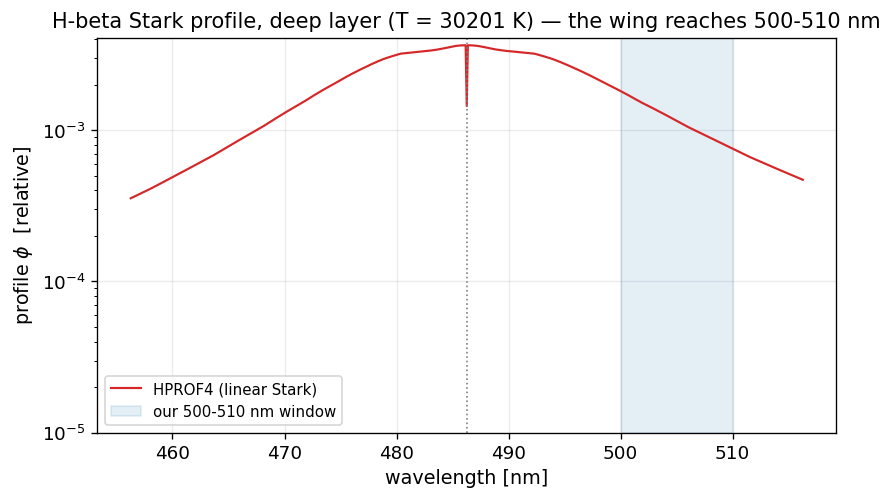

In [13]:
di = n_depths - 1; hyd = hydrogen_state(di)
off, wt_f, nf = fine_map[(2, 4)]

# +/- 30 nm around H-beta
dl = np.linspace(-30.0, 30.0, 601)
phi = np.array([hydrogen_line_profile(2, 4, d, hyd, tabs, off, wt_f, nf) for d in dl])

fig, ax = plt.subplots()
ax.semilogy(486.27 + dl, np.maximum(phi, 1e-12), color="C3", lw=1.3, label="HPROF4 (linear Stark)")
ax.axvspan(500, 510, color="C0", alpha=0.12, label="our 500-510 nm window")
ax.axvline(486.27, color="0.5", ls=":", lw=1); ax.set_ylim(1e-5, None)
ax.set_xlabel("wavelength [nm]")

# arbitrary (relative) profile units
ax.set_ylabel(r"profile $\phi$  [relative]")
ax.set_title(f"H-beta Stark profile, deep layer (T = {T[di]:.0f} K) — the wing reaches 500-510 nm")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

The profile centred at 486 nm has a core, but its **wing stays high** — high enough that at 500–510 nm, nearly 20 nm away, it is still well above the floor. The wing follows the Holtsmark form (asymptotically $\beta^{-5/2}$), but the point is the *scale*: the linear-Stark width is so large that a Lorentzian built from H$\beta$'s non-Stark damping widths would have collapsed far below this curve long before 500 nm. This persistent wing is the physical reason hydrogen contributes a smooth opacity floor across our window.

(The narrow central dip is physical, not a glitch: H$\beta$ has no unshifted central Stark component, so the averaged profile is depressed exactly at line centre.)

## Forming $\kappa_0$ and walking outward from line centre

With the profile in hand, a hydrogen line enters the opacity exactly like any other line, with one new piece of bookkeeping (the continuum-merge taper). The line-strength prefactor is the same line-centre opacity we built in the line-list lecture (Lecture 5),

$$
\kappa_0 = \underbrace{\frac{0.026538}{\sqrt\pi}\,\frac{gf}{\nu}}_{\rm cgf}\;\cdot\;\frac{n_{\rm H}}{\rho\,v_D}\;\cdot\;e^{-\chi/kT},
$$

with $gf$ the oscillator strength times statistical weight, $\nu$ the line-centre frequency, $n_{\rm H}/(\rho\,v_D)$ the population per gram per Doppler width, and $e^{-\chi/kT}$ the Boltzmann factor for the lower level ($\chi$ is its excitation energy). The opacity at a grid point is $\kappa_0\,\phi(\Delta\lambda)$ times the stimulated-emission factor $1 - e^{-h\nu/kT}$.

The walk starts at the line-centre grid index and steps outward in both directions, adding $\kappa_0\,\phi$ at each point, and **stops** when the contribution drops below the cutoff fraction ($10^{-3}$) of the continuum. The new piece is the **continuum-merge taper**: near the series limit the high Balmer lines crowd together (their spacing vanishes at large upper level $n$) and merge into the continuum, so the engine defines a merge wavelength `wcon` (inside which the line is folded into the continuum and skipped) and a taper wavelength `wtail` (over which the profile is linearly ramped down). For the well-separated low Balmer lines this taper is inactive, but we carry it so the code reads as the full engine. A few constants and small helpers first.

In [14]:
# the cgf prefactor constant (1/sqrt(pi) folded in)
CGF_CONSTANT = 0.026538 / 1.77245

C_LIGHT_NM   = 2.99792458e17            # nm/s
H_PLANCK = 6.62607015e-27; K_BOLTZ = 1.380649e-16

# stop the wing when below 1e-3 * continuum
CUTOFF = 1e-3

print("kappa0 prefactor constants ready")

kappa0 prefactor constants ready


The Boltzmann factor must be evaluated with the *production code's* tabulated $e^{-x}$ (FASTEX), not NumPy's, because the tiny rounding difference would show up at the bit level in the benchmark. FASTEX splits $x$ into an integer and a thousandths part and multiplies two precomputed tables.

In [15]:
# FASTEX: the production code's tabulated exp(-x) (matters at the bit level for the Boltzmann factor)
_EXTAB  = np.exp(-np.arange(1001, dtype=np.float64))           # exp(-integer part)
_EXTABF = np.exp(-np.arange(1001, dtype=np.float64) * 0.001)   # exp(-thousandths part)
def fast_ex_array(x):
    v = np.asarray(x, float); out = np.empty_like(v)
    out[v == 0.0] = 1.0                                        # exp(0) = 1
    neg = v < 0.0; out[neg] = np.exp(-v[neg])                  # negative x: exact exp
    pos = v > 0.0
    if np.any(pos):
        p = v[pos]; i = np.floor(p).astype(np.int64)           # integer part
        tab = i < _EXTAB.size; po = np.empty_like(p)
        if np.any(tab):                                        # in table range: multiply the two tables
            it = i[tab]; j = np.clip(np.floor((p[tab]-it)*1000.0 + 0.5).astype(np.int64), 0, _EXTABF.size-1)
            po[tab] = _EXTAB[it]*_EXTABF[j]
        if np.any(~tab): po[~tab] = np.exp(-p[~tab])           # out of range: fall back to exact exp
        out[pos] = po
    return out
print("FASTEX ready")

FASTEX ready


One more helper: the synthesis grid is logarithmic, so the line-centre grid index is found from the log of the wavelength, exactly as the production code's `IXWL` does.

In [16]:
def center_index(grid, value):
    """Log-grid centre index: IXWL = int(log(wl)/ratiolg + 0.5), offset to the grid origin."""

    # log spacing of the grid
    ratiolg = np.log(grid[1]/grid[0])

    # index of the grid origin
    ix0 = int(np.log(grid[0])/ratiolg + 0.5)

    return int(np.log(value)/ratiolg + 0.5) - ix0

print("center_index ready")

center_index ready


## The continuum-merge limits: `wcon`, `wtail`, and the neighbour cutoffs

The merge bookkeeping needs the hydrogen level energies (to locate the neighbouring Balmer lines $m\pm1$, $m\pm2$, whose overlap defines where the wing should stop) and the per-depth **Inglis–Teller** merge level: at high $n_e$ the high-$n$ lines blur into the continuum at a principal quantum number $n_{\rm merge} \approx 1600\,n_e^{-2/15}$, which fixes the merge frequency. The cutoffs `redcut`, `bluecut` mark where the engine begins checking whether a *neighbouring* line ($m\pm2$) dominates, terminating the current line's wing if it does (the bound-free continuum handoff is handled separately by `wcon`); `wlminus1/2`, `wlplus1/2` are the wavelengths of the neighbouring upper levels; `wcon` is the per-depth merge wavelength and `wtail` the taper boundary. For the three low Balmer lines in our window these limits sit well outside 500–510 nm, so the taper never fires here — but the code computes them exactly as the engine does.

In [17]:
# H level energies (cm^-1), n=1..8; above n=8 use the Rydberg formula
_EHYD_CM = np.array([0.0, 82259.105, 97492.302, 102823.893, 105291.651,
                     106632.160, 107440.444, 107965.051])
_RYD_CM, _EINF_CM = 109677.576, 109678.764
conth = C["conth"]                                             # continuum-edge wavenumbers per lower level

def ehyd_cm(nn):
    """Energy of hydrogen level nn in cm^-1 (table for low nn, Rydberg formula above)."""
    if nn <= 0: return 0.0
    return float(_EHYD_CM[nn-1]) if nn-1 < _EHYD_CM.size else _EINF_CM - _RYD_CM/float(nn*nn)
print("level energies ready")

level energies ready


The per-depth merge frequency comes from the **Inglis–Teller** relation: at electron density $n_e$ the Balmer lines blur into the continuum above a principal quantum number $n_{\rm merge} \approx 1600\,n_e^{-2/15}$. Convert that level to a wavenumber per depth, then `merge_limits` turns it (and the line's own continuum edge) into the merge wavelength `wcon` and taper boundary `wtail`.

In [18]:
# Inglis-Teller merge level -> merge wavenumber per depth

# principal quantum number where lines merge
inglis  = 1600.0 / np.power(xne, 2.0/15.0)
nmerge  = np.maximum(inglis - 1.5, 1.0)

# energy of that level
emerge_h = _RYD_CM / np.maximum(nmerge*nmerge, 1e-12)          # cm^-1

def merge_limits(nl, nu, di, conth_val, wshift):
    """Per-depth continuum-merge wavelength wcon and taper boundary wtail (nm)."""

    # merge wavelength from the Inglis-Teller level
    denom = conth_val - emerge_h[di]
    wmerge = 1.0e7/denom if denom > 0.0 else (wshift + wshift)
    wcon = max(wshift, wmerge)

    # taper spans 500 cm^-1 inward of wcon
    inner = 1.0e7/wcon - 500.0 if wcon > 0.0 else -1.0
    wtail = 1.0e7/inner if inner > 0.0 else wcon + wcon

    # clamp both to sane bounds
    wcon  = min(wshift + wshift, wcon)
    if wtail < 0.0: wtail = wcon + wcon
    wtail = min(wcon + wcon, wtail)

    return wcon, wtail

print("merge limits ready")

merge limits ready


## The accumulation walk for one line at one depth

The walk itself. Starting at the line-centre index, it steps outward in offset, evaluating the profile at each grid point on the red and blue sides and adding $\kappa_0\,\phi\cdot(1-e^{-h\nu/kT})$ to the opacity buffer. It stops a side when the value falls below $10^{-3}$ of the continuum (the same cutoff metals use). The `simple` flag (true when $m\le n+2$) takes the plain symmetric march; the `wcon`/`wtail` taper and the neighbour-cutoff logic only engage for the higher, crowded lines. Of our three Balmer lines this is true only for H$\beta$ ($m=4$); for H$\gamma$ ($m=5$) and H$\delta$ ($m=6$) the flag is false, but their taper and neighbour limits sit well outside 500–510 nm, so the walk through our window is unperturbed either way. We keep the full branch so the engine is reproduced faithfully.

In [19]:
def accumulate(buffer, cont_row, stim_row, grid, ci, line_wl, kappa0, nl, nu,
               wcon, wtail, wlm1, wlm2, wlp1, wlp2, redcut, bluecut, cutoff,
               hyd, tabs, foff, fwt, n_fine):
    npts = buffer.shape[0]
    simple = nu <= nl + 2                                       # plain march (m<=n+2; true for H-beta here)
    taper  = (not simple) and (wtail > wcon)                    # is the continuum-merge taper active?
    um2 = max(nu - 2, nl + 1); up2 = nu + 2                     # the neighbour upper levels m-2, m+2
    def prof(a, b, dl):                                         # shorthand for the profile evaluation
        return hydrogen_line_profile(a, b, dl, hyd, tabs, foff, fwt, n_fine)
    red, blue = True, True; off = 1                             # both sides live; step counter
    msteps = max(ci, npts - ci - 1)                             # furthest we could ever need to walk
    # --- line centre ---
    if 0 <= ci < npts:
        wave = grid[ci]
        if not (not simple and wave < wcon):                    # skip if folded into the continuum
            v = kappa0 * prof(nl, nu, wave - line_wl) * stim_row[ci]
            if taper and wave < wtail: v *= (wave - wcon)/(wtail - wcon)   # linear taper ramp
            if v >= cont_row[ci]*cutoff: buffer[ci] += v        # accumulate if above cutoff
    elif ci >= npts:
        red = False; off = max(1, ci - (npts - 1))              # centre off the red edge: walk blue only
    else:
        blue = False; off = max(1, -ci)                         # centre off the blue edge: walk red only
    # --- march outward, one offset at a time, on each live side ---
    while off <= msteps and (red or blue):
        if red:
            idx = ci + off                                      # red side: increasing wavelength
            if idx >= npts: red = False                         # ran off the grid
            else:
                wave = grid[idx]
                if not simple:
                    if wave > wlm1: red = False                 # reached the neighbour line: stop
                    elif wave < wcon: pass                      # inside the merge region: skip point
                    else:
                        v = kappa0*prof(nl, nu, wave - line_wl)*stim_row[idx]
                        if taper and wave < wtail: v *= (wave - wcon)/(wtail - wcon)
                        if wave > redcut:                       # neighbour overlap: stop if it dominates
                            v2 = kappa0*prof(nl, um2, wave - wlm2)*stim_row[idx]
                            if taper and wave < wtail: v2 *= (wave - wcon)/(wtail - wcon)
                            if v2 >= v: red = False; v = 0.0
                        if v <= 0.0 or v < cont_row[idx]*cutoff: red = False   # dropped below cutoff: stop
                        else: buffer[idx] += v
                else:                                           # simple line: plain march, no taper/neighbour
                    v = kappa0*prof(nl, nu, wave - line_wl)*stim_row[idx]
                    if v <= 0.0 or v < cont_row[idx]*cutoff: red = False
                    else: buffer[idx] += v
        if blue:
            idx = ci - off                                      # blue side: decreasing wavelength
            if idx < 0: blue = False                            # ran off the grid
            else:
                wave = grid[idx]
                if not simple and (wave < wcon or wave < wlp1): blue = False   # merge region / neighbour: stop
                else:
                    v = kappa0*prof(nl, nu, wave - line_wl)*stim_row[idx]
                    if not simple:
                        if taper and wave < wtail: v *= (wave - wcon)/(wtail - wcon)   # taper ramp
                        if wave < bluecut:                      # neighbour overlap: stop if it dominates
                            v2 = kappa0*prof(nl, up2, wave - wlp2)*stim_row[idx]
                            if taper and wave < wtail: v2 *= (wave - wcon)/(wtail - wcon)
                            if v2 >= v: blue = False; v = 0.0
                    if v <= 0.0 or v < cont_row[idx]*cutoff: blue = False   # dropped below cutoff: stop
                    else: buffer[idx] += v
        off += 1                                                # next offset outward
print("accumulation walk ready")

accumulation walk ready


## The driver: every Balmer line, every depth

The driver loops the three Balmer lines over the eighty layers. For each line it builds the line-centre index, the cgf prefactor, the neighbour and merge limits, and the per-line Boltzmann factor; for each depth it forms $\kappa_0$, checks it against the continuum cutoff (skip the line at this depth if it is too weak to register), assembles the per-depth state, and runs the accumulation walk into the opacity array. The stimulated-emission factor $1 - e^{-h\nu/kT}$ is evaluated on the grid once.

In [20]:
def compute_hydrogen_opacity():
    grid = wl
    # stimulated-emission factor on the grid, per depth
    hkt = H_PLANCK/(K_BOLTZ*T)
    stim = 1.0 - np.exp(-(C_LIGHT_NM/grid)[None, :] * hkt[:, None])
    hckt = A["hckt"]
    wl_all = C["cat_wl"]; idx_all = C["cat_index_wl"]; gf_all = C["cat_gf"]
    nl_all = C["cat_n_lower"].astype(np.int64); nu_all = C["cat_n_upper"].astype(np.int64)
    elow_all = C["cat_elow"]
    pop3 = A["population_per_ion"][:, :, 0]   # H is element index 0
    dop3 = A["doppler_per_ion"][:, :, 0]
    rho  = A["mass_density"]
    ahline = np.zeros((n_depths, grid.size))

    for li in hidx:
        # --- per-line setup: centre, strength, and the neighbour/merge limits ---
        line_wl = float(wl_all[li]); ci = center_index(grid, float(idx_all[li]))   # line-centre grid index
        cgf = CGF_CONSTANT * float(gf_all[li]) / (C_LIGHT_NM/line_wl)              # the cgf strength prefactor
        nl = max(int(nl_all[li]), 1); nu = max(int(nu_all[li]), nl+1)             # lower/upper levels
        elo = ehyd_cm(nl)                                                          # lower-level energy (cm^-1)
        wlm1 = (1.0e7/(ehyd_cm(nu-1)-elo)) if nu-1 > nl else line_wl              # neighbour m-1 wavelength
        wlm2 = (1.0e7/(ehyd_cm(nu-2)-elo)) if nu-2 > nl else line_wl              # neighbour m-2 wavelength
        wlp1 = 1.0e7/(ehyd_cm(nu+1)-elo);  wlp2 = 1.0e7/(ehyd_cm(nu+2)-elo)        # neighbours m+1, m+2
        redcut  = 1.0e7/(conth[0] - _RYD_CM/(nu-0.8)**2 - elo)                     # red neighbour-overlap cutoff
        bluecut = 1.0e7/(conth[0] - _RYD_CM/(nu+0.8)**2 - elo)                     # blue neighbour-overlap cutoff
        conth_val = float(conth[max(1, min(nl, conth.size))-1])                    # continuum edge for this series
        wshift = 1.0e7/(conth_val - _RYD_CM/81.0**2)                               # reference wavelength scale
        off_f, wt_f, nf = fine_map.get((nl, nu), (np.zeros(1), np.zeros(1), 0))     # fine-structure components
        boltz = fast_ex_array(elow_all[li] * hckt)             # Boltzmann factor per depth

        for di in range(n_depths):
            pv = pop3[di, 0]; dv = dop3[di, 0]; rd = float(rho[di])   # population, Doppler width, density
            if pv <= 0.0 or dv <= 0.0 or rd <= 0.0: continue          # skip unphysical/empty layers
            kapmin = cont[di, max(0, min(ci, grid.size-1))] * CUTOFF  # the per-depth cutoff opacity
            k0pre = cgf * pv/(rd*dv)                                  # kappa0 without the Boltzmann factor
            if k0pre < kapmin: continue                              # too weak even before Boltzmann: skip
            kappa0 = k0pre * boltz[di]                                # full line-centre opacity
            if kappa0 < kapmin: continue                             # still below cutoff: skip this layer
            hyd = hydrogen_state(di)                                  # per-depth profile coefficients
            wcon, wtail = merge_limits(nl, nu, di, conth_val, wshift) # per-depth merge/taper limits
            accumulate(ahline[di], cont[di], stim[di], grid, ci, line_wl, kappa0, nl, nu,
                       wcon, wtail, wlm1, wlm2, wlp1, wlp2, redcut, bluecut, CUTOFF,
                       hyd, tabs, off_f, wt_f, nf)                    # walk the wing into the opacity array
    return ahline

ahline = compute_hydrogen_opacity()
print("hydrogen-line opacity computed:", ahline.shape,
      f"  max = {ahline.max():.3e} cm^2/g")

hydrogen-line opacity computed: (80, 5941)   max = 5.735e+04 cm^2/g


## Benchmark: machine precision against the reference

Compare to the reference hydrogen-line opacity the production code wrote into the data file (`gt_ahline`). We measure the relative difference where the reference is non-zero, and report the maximum and median.

In [21]:
big = gt_ahline > 1e-10                                          # compare only where the reference is non-zero
rel = np.abs(ahline[big] - gt_ahline[big]) / np.abs(gt_ahline[big])   # relative error per point
print(f"hydrogen-line opacity vs reference (|ref| > 1e-10, N = {big.sum()}):")
print(f"  max relative error    = {rel.max():.3e}")
print(f"  median relative error = {np.median(rel):.3e}")
assert rel.max() < 1e-9, "benchmark not at machine precision"
print("\\nPASS: reproduced to machine precision (~1e-15)")

hydrogen-line opacity vs reference (|ref| > 1e-10, N = 119419):
  max relative error    = 8.060e-16
  median relative error = 0.000e+00
\nPASS: reproduced to machine precision (~1e-15)


**Machine precision.** The from-scratch HPROF4 engine reproduces the reference hydrogen-line opacity to a maximum relative error of order $10^{-15}$ — the floating-point floor — with a median of exactly zero. Every piece is matched: the Holtsmark microfield, the `sofbeta` quasi-static profile interpolated in the Stark tables, the electron-impact width through the exponential integrals, the Doppler core over fine-structure components, the Lorentzian, and the outward walk with its continuum cutoff. This is the hydrogen contribution to the line opacity, rebuilt exactly.

## The H$\beta$ Stark wing across the window, and with depth

Two views of what we built. First, the hydrogen-line opacity across 500–510 nm at three depths, chosen so all three carry measurable H-line opacity: a warm layer ($\sim 8000$ K), a hot layer ($\sim 12000$ K), and the deepest, hottest layer ($\sim 30000$ K). The opacity is a **smooth floor** — no line cores, because the line centres are outside the window — and it climbs by **orders of magnitude** between these layers. That steep climb is the physics, not a plotting artefact: the wing strength is the product of the $n=2$ lower-level population (Boltzmann excitation), the neutral-hydrogen fraction (Saha ionisation), and the Stark width itself (which grows with $F_0 \propto n_e^{2/3}$). All three rise with depth, so the deep-layer floor stands four to six orders of magnitude above the warm-layer one. Cooler than this — through the photosphere and the cool surface — the wing never clears the $10^{-3}$ continuum cutoff anywhere in the window, so the engine deposits nothing and the hydrogen-line opacity there is exactly zero. Second, the residual against the reference, at the floating-point floor across the whole window.

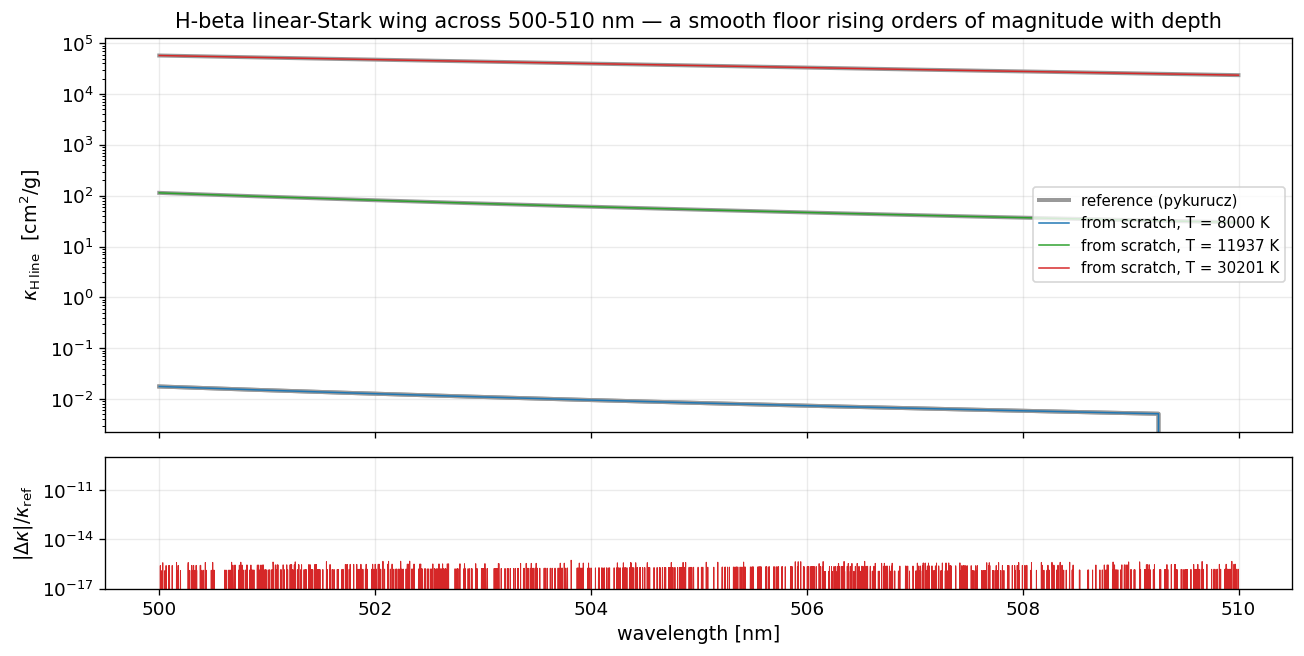

deep-layer floor at 500 nm: 5.735e+04 cm^2/g  (reference 5.735e+04)
  T =   8000 K:  max kappa_Hline = 1.775e-02 cm^2/g
  T =  11937 K:  max kappa_Hline = 1.141e+02 cm^2/g
  T =  30201 K:  max kappa_Hline = 5.735e+04 cm^2/g


In [22]:
# three depths chosen so each carries measurable H-line opacity (~8000/12000/30000 K)
depths = [int(np.argmin(np.abs(T - tt))) for tt in (8000.0, 12000.0, 30000.0)]

fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})

# grey reference under each from-scratch curve (one shared legend entry)
ax.plot(wl, gt_ahline[depths[0]], color="0.6", lw=2.4, label="reference (pykurucz)")
for d, c in zip(depths, ["C0", "C2", "C3"]):
    ax.plot(wl, gt_ahline[d], color="0.6", lw=2.4)
    ax.plot(wl, ahline[d], color=c, lw=0.9, label=f"from scratch, T = {T[d]:.0f} K")

ax.set_yscale("log")
# cm^2/g
ax.set_ylabel(r"$\kappa_{\rm H\,line}$  [cm$^2$/g]")
ax.set_title("H-beta linear-Stark wing across 500-510 nm — a smooth floor rising orders of magnitude with depth")
ax.legend(loc="center right", fontsize=9)

# bottom panel: |from-scratch - reference| / reference at the deepest layer
rel_w = np.abs(ahline[n_depths-1] - gt_ahline[n_depths-1]) / np.maximum(gt_ahline[n_depths-1], 1e-300)
axr.semilogy(wl, np.maximum(rel_w, 1e-18), color="C3", lw=0.6)
axr.set_xlabel("wavelength [nm]")
axr.set_ylabel(r"$|\Delta\kappa|/\kappa_{\rm ref}$")
axr.set_ylim(1e-17, 1e-9)

fig.tight_layout(); plt.show()

print(f"deep-layer floor at 500 nm: {ahline[-1, 0]:.3e} cm^2/g  "
      f"(reference {gt_ahline[-1, 0]:.3e})")
for d in depths:
    print(f"  T = {T[d]:6.0f} K:  max kappa_Hline = {ahline[d].max():.3e} cm^2/g")

The reproduced curves lie exactly on the reference (grey) at every depth, and they are clearly **distinct**: the $\sim 8000$ K floor sits near $10^{-2}$ cm$^2$/g, the $\sim 12000$ K floor near $10^{2}$, and the $\sim 30000$ K floor reaches $\sim 5.7\times10^4$ cm$^2$/g at the blue edge before falling smoothly toward the red as the H$\beta$ wing thins away from its 486 nm centre. That spread is the temperature dependence of the lower-level population and the ionisation balance, written into the opacity. The residual panel stays at the floating-point floor across the window. This is the opacity the metal-and-helium line list does not contain, supplied by the one engine in the pipeline that does not use a Voigt profile.

## Synthesis

The line-list lecture broadened every line with a Voigt profile, and that was right for metals and helium, whose levels shift quadratically with an electric field. Hydrogen is degenerate, so its levels shift **linearly**, and its lines are broadened by the **electric microfield** of the surrounding plasma rather than by a single lifetime damping width. This lecture built the dedicated engine for that physics. The Holtsmark normal field $F_0 = 1.25\times10^{-9}\,n_e^{2/3}$ set the scale; the dimensionless detuning $\beta = \Delta\nu/F_0\cdot\mathrm{d}\beta$ became the variable the whole profile depends on; and the profile itself was a sum of three pieces — a Doppler core over fine-structure components, a Lorentzian from the non-Stark widths, and the broad linear-Stark wing from the quasi-static Holtsmark profile `sofbeta` plus an electron-impact term — selected by which half-width dominates. Folded into the same $\kappa_0$ and the same outward walk the rest of the pipeline uses, it reproduces the reference hydrogen-line opacity to machine precision.

The concrete result for our window is the dominant **H$\beta$ Stark wing**: a line centred 19 nm away whose $\beta^{-5/2}$ tail is broad enough to deposit a smooth opacity floor across 500–510 nm, climbing to $\sim 5.7\times10^4$ cm$^2$/g in the deepest layers. The driver also accumulates the more distant H$\gamma$ and H$\delta$ wings, but their contribution here is small. With the metal/helium Voigt kernel (line-list lecture) and this hydrogen Stark engine, the line opacity in this window is complete for the reference synthesis under the Kurucz/pykurucz assumptions, and the pipeline has every line absorber it needs there.

## Summary

- **Hydrogen broadens differently.** Its degenerate levels shift **linearly** with an electric field (the linear Stark effect), so its lines are broadened by the plasma **microfield**, not by a damping rate — a Voigt profile cannot represent the resulting $\Delta\nu^{-5/2}$ wing.
- **The Holtsmark microfield.** The normal field strength is $F_0 = 1.25\times10^{-9}\,n_e^{2/3}$, and the profile is a function of the dimensionless detuning $\beta = \Delta\nu/F_0\cdot\mathrm{d}\beta$ and a weak pressure parameter $p$.
- **Three pieces.** The HPROF4 profile sums a Doppler **core** (Gaussians over fine-structure components), a **Lorentzian** (resonance + radiative + van der Waals half-widths), and the **linear-Stark wing** (the quasi-static `sofbeta` Holtsmark profile interpolated in the Stark tables, plus an electron-impact Lorentzian), selecting the dominant piece in the core and the sum in the wing.
- **Same opacity machinery.** The line enters with the usual $\kappa_0 = \mathrm{cgf}\cdot n/(\rho v_D)\cdot e^{-\chi/kT}$ and an outward walk that stops below $10^{-3}$ of the continuum, with an added continuum-merge taper (inactive for the low Balmer lines).
- **The window's opacity floor.** The H$\beta$ wing reaches across 500–510 nm as a smooth floor climbing to $\sim 5.7\times10^4$ cm$^2$/g in the deep layers — the contribution the metal/He line list omits.
- **Machine precision.** The rebuilt engine matches the reference hydrogen-line opacity to a maximum relative error of $\sim$$10^{-15}$ (median exactly zero).

## Practice exercises

**1. The field scaling.** Plot the Holtsmark field $F_0 = 1.25\times10^{-9}\,n_e^{2/3}$ against depth, and overlay the hydrogen opacity at 500 nm. Confirm that the opacity correlates strongly with increasing $F_0$ (and so with $n_e$), while noting that the scaling is *not* a clean power of $F_0$: the lower-level population, the ionisation balance, the stimulated-emission factor, and the $\beta$-dependent profile all change with depth as well. Explain why the Stark wing is negligible at the cool surface but dominant in the deep layers.

**2. The power-law wing.** Evaluate `sofbeta` over a wide range of $\beta$ (say $1$ to $10^4$) at a fixed $p$ and fit the slope of $\log S$ versus $\log\beta$ in the far wing. Recover the Holtsmark exponent $-5/2$. Note that this is *steeper* than a Lorentzian's $-2$: hydrogen reaches so far not because of a shallower exponent but because the linear-Stark scale $F_0$ is enormous, lifting the whole wing far above any lifetime-broadened Lorentzian.

**3. Which piece dominates where.** Inside `hydrogen_line_profile`, print the three half-widths (Doppler, Lorentz, Stark) and the flag `nwid` for H$\beta$ at a photospheric and a deep layer, sampled at line centre and at 505 nm. Verify that the Stark width dominates the deep-layer wing and the Doppler width the cool-layer core.

**4. Removing the wing.** Zero the Stark contribution (return only `core + lorentz` from the profile) and re-run the driver. Compare the deep-layer line opacity at 500 nm to the full result, and to the continuum at that depth — quantify how much of the deep-layer line opacity in the window is the H$\beta$ Stark wing, and what fraction of the continuum it represents.

## Further reading

- **Holtsmark, J. (1919). *Ann. Phys.* 363, 577.** The original statistical theory of the electric microfield in a plasma, whose field-strength distribution underlies the $\beta^{-5/2}$ wing.
- **Griem, H. R. (1974). *Spectral Line Broadening by Plasmas*, Academic Press.** The standard reference on Stark broadening of hydrogen lines — quasi-static ions, electron impact, and the unified profile the HPROF4 tables encode.
- **Vidal, C. R., Cooper, J. & Smith, E. W. (1973). *ApJ Suppl.* 25, 37.** The VCS tables of hydrogen Stark profiles, the lineage of the `sofbeta`/`propbm` statistical-broadening tables used here.
- **Stehlé, C. & Hutcheon, R. (1999). *Astron. Astrophys. Suppl.* 140, 93.** Modern computed Balmer-line Stark profiles, useful for comparing the engine's profile against an independent calculation.
- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge.** Chapter 11 on hydrogen-line broadening and the linear Stark effect in cool-star photospheres.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference hydrogen-line opacity is computed with.